NUESTROS DATOS LOS HEMOS OBTENIDO A TRAVES DEL PORTAL DE ENCUESTAS EUROPEO https://ess.sikt.no/en/data-builder/?tab=variables.
NUESTRA HIPOTESIS NULA ES QUE EL ESTADO ECONOMICO  Y LA CULTURA REGIONAL INFLUYE EN LA OPINION GENERAL Y EN LA ADOPCION DE IDEOLOGIAS POLITICAS.
Tenemos 3 grandes grupos respecto a la Media economica europea, teniendo en cuenta la inflacion y el sueldo bruto anual.
Nuestra Variable target será 'lrscale' escala de ideologia politica 0=extrema izquierda y 10= extrema derecha.
Grupo 1: Alemania (Superior a la Media Europea)
Grupo 2: España (Media Europea)
Grupo 3: Hungria  (Inferior a la media)

In [1]:
import pandas as pd
import random
import numpy as np, random
random.seed(42)

In [2]:
#Cargamos todos los csv.
#Grupo 1:
df_deu= pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/raw/DeuData.csv')

In [3]:
df_deu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36845 entries, 0 to 36844
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      36845 non-null  object 
 1   essround  36845 non-null  int64  
 2   edition   36845 non-null  float64
 3   proddate  36845 non-null  object 
 4   idno      36845 non-null  int64  
 5   cntry     36845 non-null  object 
 6   dweight   36845 non-null  float64
 7   pspwght   36845 non-null  float64
 8   pweight   36845 non-null  float64
 9   anweight  31059 non-null  float64
 10  prob      13503 non-null  float64
 11  stratum   13503 non-null  float64
 12  psu       13503 non-null  float64
 13  pplhlp    36845 non-null  int64  
 14  ppltrst   36845 non-null  int64  
 15  lawobey   2919 non-null   float64
 16  lrscale   36845 non-null  int64  
 17  stfgov    36845 non-null  int64  
 18  trstep    36845 non-null  int64  
 19  trstlgl   36845 non-null  int64  
 20  trstplc   36845 non-null  in

In [4]:
#Eliminamos columnas del df que no interesen
columnas_a_eliminar = ['name', 'essround', 'edition', 'proddate', 'idno', 'dweight', 'pspwght', 'pweight', 'anweight', 'prob', 'stratum', 'psu']
df_deu.drop(columnas_a_eliminar, axis=1, inplace=True)

In [5]:
#Obtenemos una lista con los nombres de las columnas restantes.
nombres_columnas = df_deu.columns.tolist()
print(nombres_columnas)

['cntry', 'pplhlp', 'ppltrst', 'lawobey', 'lrscale', 'stfgov', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'happy']


In [6]:

#Observamos que las variables lawobey y trstsci son las que tienen datos faltantes.
import pandas as pd
import numpy as np

datadeu = {
    'lawobey': {
        1: 0.019,
        2: 0.532,
        3: 0.149,
        4: 0.115,
        5: 0.012,
    },
    'trstsci': {
        0: 0.006,
        1: 0.002,
        2: 0.011,
        3: 0.012,
        4: 0.019,
        5: 0.062,
        6: 0.09,
        7: 0.246,
        8: 0.324,
        9: 0.185,
        10: 0.046,
    }
}

def rngpond(df, datadeu):
    """
    Rellena los datos faltantes en un DataFrame usando valores aleatorios
    generados según los pesos ponderados proporcionados en el diccionario datadeu.
    """
    for columna, pesos in datadeu.items():
        if columna in df.columns and df[columna].isnull().any():
            valores = np.array(list(pesos.keys()))
            pesos_ponderados = np.array(list(pesos.values()))

            # Normalizar los pesos ponderados
            suma_pesos = np.sum(pesos_ponderados)
            pesos_normalizados = pesos_ponderados / suma_pesos

            for index, row in df[df[columna].isnull()].iterrows():
                # Generar un valor aleatorio según los pesos ponderados normalizados
                valor_aleatorio = np.random.choice(valores, p=pesos_normalizados)

                # Rellenar el valor faltante con el valor aleatorio generado
                df.loc[index, columna] = valor_aleatorio
    return df

# Supongamos que df_deu es tu DataFrame original
# df_deu = ... # Carga tu DataFrame aquí

df_deuv2 = rngpond(df_deu.copy(), datadeu)

print(df_deuv2.isnull().sum())

cntry         0
pplhlp        0
ppltrst       0
lawobey       0
lrscale       0
stfgov        0
trstep        0
trstlgl       0
trstplc       0
trstplt       0
trstprl       0
trstprt    2919
trstun        0
trstsci       0
happy         0
dtype: int64


In [7]:
#Rellenamos la variable 'trstprt' con la moda
moda_trstprt = df_deuv2['trstprt'].mode()[0]
df_deuv2['trstprt'].fillna(moda_trstprt, inplace=True)

C:\Users\Josue;\AppData\Local\Temp\ipykernel_7500\2301469211.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_deuv2['trstprt'].fillna(moda_trstprt, inplace=True)


In [8]:
#Eliminamos los valores nulos de las columnas, que hacen referencia a que el encuestado no ha querido responder. valores 77,88,99
import pandas as pd
import numpy as np

def delnulos(df):
    """
    Filtra el DataFrame df_deuv2 y sobreescribe el DataFrame original
    con los resultados filtrados.
    """
    columnas_a_limpiar = ['pplhlp', 'ppltrst', 'lrscale', 'stfgov', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'happy']
    for columna in columnas_a_limpiar:
        if columna in df.columns:
            df[columna] = np.where(df[columna] > 70, np.nan, df[columna])
            df.dropna(subset=[columna], inplace=True)
    return df

df_deuv2 = delnulos(df_deuv2)
print(df_deuv2.isnull().sum())

cntry      0
pplhlp     0
ppltrst    0
lawobey    0
lrscale    0
stfgov     0
trstep     0
trstlgl    0
trstplc    0
trstplt    0
trstprl    0
trstprt    0
trstun     0
trstsci    0
happy      0
dtype: int64


In [9]:
import pandas as pd
import numpy as np, random
#Reducimos el dataframe al 10%
tamano_muestra = int(len(df_deuv2) * 0.1)
np.random.seed(42)  
indices_aleatorios = np.random.choice(df_deuv2.index, size=tamano_muestra, replace=False)
df_deuv2_reducido = df_deuv2.loc[indices_aleatorios]
df_deuv2_reindexado = df_deuv2_reducido.reset_index(drop=True)
print(len(df_deuv2_reducido))

3153


In [10]:
#Borramos datos de la cache excepto nuestro dataframe final de Alemania.
del columnas_a_eliminar, datadeu, df_deuv2, df_deu, df_deuv2_reducido, nombres_columnas, indices_aleatorios

In [11]:
#Guardamos el dataframe de alemania en un csv en la carpeta processed
import pandas as pd
# Ruta completa al archivo CSV
ruta_completa_archivo = 'C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_deu.csv'

# Guarda el DataFrame en el archivo CSV
df_deuv2_reindexado.to_csv(ruta_completa_archivo, index=False)

In [12]:
#Grupo 2 España (Media UE).
df_spa= pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/raw/SpaData.csv')

In [13]:
#Eliminamos columnas del df que no interesen
columnas_a_eliminar = ['name', 'essround', 'edition', 'proddate', 'idno', 'dweight', 'pspwght', 'pweight', 'anweight', 'prob', 'stratum', 'psu']
df_spa.drop(columnas_a_eliminar, axis=1, inplace=True)

In [14]:
#Obtenemos una lista con los nombres de las columnas restantes.
nombres_columnas = df_spa.columns.tolist()
print(nombres_columnas)

['cntry', 'pplhlp', 'ppltrst', 'lawobey', 'lrscale', 'stfgov', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'happy']


In [15]:
df_spa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21296 entries, 0 to 21295
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cntry    21296 non-null  object 
 1   pplhlp   21296 non-null  int64  
 2   ppltrst  21296 non-null  int64  
 3   lawobey  1729 non-null   float64
 4   lrscale  21296 non-null  int64  
 5   stfgov   21296 non-null  int64  
 6   trstep   21296 non-null  int64  
 7   trstlgl  21296 non-null  int64  
 8   trstplc  21296 non-null  int64  
 9   trstplt  21296 non-null  int64  
 10  trstprl  21296 non-null  int64  
 11  trstprt  19567 non-null  float64
 12  trstun   21296 non-null  int64  
 13  trstsci  2283 non-null   float64
 14  happy    21296 non-null  int64  
dtypes: float64(3), int64(11), object(1)
memory usage: 2.4+ MB


In [16]:
dataspa = {
    'lawobey': {
        1: 0.0222,
        2: 0.435,
        3: 0.23,
        4: 0.094,
        5: 0.02,
    },
    'trstsci': {
        0: 0.011,
        1: 0.003,
        2: 0.018,
        3: 0.028,
        4: 0.039,
        5: 0.075,
        6: 0.132,
        7: 0.217,
        8: 0.252,
        9: 0.136,
        10: 0.088,
    }
}

def rngpond(df, dataspa):
    """
    Rellena los datos faltantes en un DataFrame usando valores aleatorios
    generados según los pesos ponderados proporcionados en el diccionario datadeu.
    """
    for columna, pesos in dataspa.items():
        if columna in df.columns and df[columna].isnull().any():
            valores = np.array(list(pesos.keys()))
            pesos_ponderados = np.array(list(pesos.values()))

            # Normalizar los pesos ponderados
            suma_pesos = np.sum(pesos_ponderados)
            pesos_normalizados = pesos_ponderados / suma_pesos

            for index, row in df[df[columna].isnull()].iterrows():
                # Generar un valor aleatorio según los pesos ponderados normalizados
                valor_aleatorio = np.random.choice(valores, p=pesos_normalizados)

                # Rellenar el valor faltante con el valor aleatorio generado
                df.loc[index, columna] = valor_aleatorio
    return df



df_spav2 = rngpond(df_spa.copy(), dataspa)

print(df_spav2.isnull().sum())

cntry         0
pplhlp        0
ppltrst       0
lawobey       0
lrscale       0
stfgov        0
trstep        0
trstlgl       0
trstplc       0
trstplt       0
trstprl       0
trstprt    1729
trstun        0
trstsci       0
happy         0
dtype: int64


In [17]:
#Rellenamos la variable 'trstprt' con la moda
moda_trstprt = df_spav2['trstprt'].mode()[0]
df_spav2['trstprt'].fillna(moda_trstprt, inplace=True)

C:\Users\Josue;\AppData\Local\Temp\ipykernel_7500\349227089.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_spav2['trstprt'].fillna(moda_trstprt, inplace=True)


In [18]:
#Eliminamos los valores nulos de las columnas, que hacen referencia a que el encuestado no ha querido responder. valores 77,88,99
import pandas as pd
import numpy as np

def delnulos(df):
    """
    Filtra el DataFrame df_deuv2 y sobreescribe el DataFrame original
    con los resultados filtrados.
    """
    columnas_a_limpiar = ['pplhlp', 'ppltrst', 'lrscale', 'stfgov', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'happy']
    for columna in columnas_a_limpiar:
        if columna in df.columns:
            df[columna] = np.where(df[columna] > 70, np.nan, df[columna])
            df.dropna(subset=[columna], inplace=True)
    return df

df_spav2= delnulos(df_spav2)
print(df_spav2.isnull().sum())

cntry      0
pplhlp     0
ppltrst    0
lawobey    0
lrscale    0
stfgov     0
trstep     0
trstlgl    0
trstplc    0
trstplt    0
trstprl    0
trstprt    0
trstun     0
trstsci    0
happy      0
dtype: int64


In [19]:
import pandas as pd
import numpy as np, random
#Reducimos el dataframe al 20%
tamano_muestra = int(len(df_spav2) * 0.2)
np.random.seed(42)  
indices_aleatorios = np.random.choice(df_spav2.index, size=tamano_muestra, replace=False)
df_spav2_reducido = df_spav2.loc[indices_aleatorios]
df_spav2_reindexado = df_spav2_reducido.reset_index(drop=True)
print(len(df_spav2_reindexado))

3219


In [20]:
#Borramos datos de la cache excepto nuestro dataframe final de España.
del columnas_a_eliminar, dataspa, df_spav2, df_spa, df_spav2_reducido, nombres_columnas, indices_aleatorios

In [21]:
#Guardamos el dataframe de españa en un csv en la carpeta processed
import pandas as pd
ruta_completa_archivo = 'C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_spa.csv'
df_spav2_reindexado.to_csv(ruta_completa_archivo, index=False)

In [22]:
#Grupo 3 Hungria(inferior  a la media UE):
df_hun= pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/raw/HungData.csv')

In [23]:
#Eliminamos columnas del df que no interesen
columnas_a_eliminar = ['name', 'essround', 'edition', 'proddate', 'idno', 'dweight', 'pspwght', 'pweight', 'anweight', 'prob', 'stratum', 'psu']
df_hun.drop(columnas_a_eliminar, axis=1, inplace=True)

In [24]:
#Obtenemos una lista con los nombres de las columnas restantes.
nombres_columnas = df_hun.columns.tolist()
print(nombres_columnas)

['cntry', 'pplhlp', 'ppltrst', 'lawobey', 'lrscale', 'stfgov', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'happy']


In [25]:
df_hun.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18760 entries, 0 to 18759
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cntry    18760 non-null  object 
 1   pplhlp   18760 non-null  int64  
 2   ppltrst  18760 non-null  int64  
 3   lawobey  1685 non-null   float64
 4   lrscale  18760 non-null  int64  
 5   stfgov   18760 non-null  int64  
 6   trstep   18760 non-null  int64  
 7   trstlgl  18760 non-null  int64  
 8   trstplc  18760 non-null  int64  
 9   trstplt  18760 non-null  int64  
 10  trstprl  18760 non-null  int64  
 11  trstprt  17075 non-null  float64
 12  trstun   18760 non-null  int64  
 13  trstsci  1849 non-null   float64
 14  happy    18760 non-null  int64  
dtypes: float64(3), int64(11), object(1)
memory usage: 2.1+ MB


In [26]:
datahun = {
    'lawobey': {
        1: 0.60,
        2: 0.326,
        3: 0.062,
        4: 0.011,
        5: 0.002,
    },
    'trstsci': {
        0: 0.011,
        1: 0.01,
        2: 0.029,
        3: 0.03,
        4: 0.053,
        5: 0.176,
        6: 0.121,
        7: 0.177,
        8: 0.197,
        9: 0.11,
        10: 0.086,
    }
}

def rngpond(df, datahun):
    """
    Rellena los datos faltantes en un DataFrame usando valores aleatorios
    generados según los pesos ponderados proporcionados en el diccionario datadeu.
    """
    for columna, pesos in datahun.items():
        if columna in df.columns and df[columna].isnull().any():
            valores = np.array(list(pesos.keys()))
            pesos_ponderados = np.array(list(pesos.values()))

            # Normalizar los pesos ponderados
            suma_pesos = np.sum(pesos_ponderados)
            pesos_normalizados = pesos_ponderados / suma_pesos

            for index, row in df[df[columna].isnull()].iterrows():
                # Generar un valor aleatorio según los pesos ponderados normalizados
                valor_aleatorio = np.random.choice(valores, p=pesos_normalizados)

                # Rellenar el valor faltante con el valor aleatorio generado
                df.loc[index, columna] = valor_aleatorio
    return df



df_hunv2 = rngpond(df_hun.copy(), datahun)

print(df_hunv2.isnull().sum())

cntry         0
pplhlp        0
ppltrst       0
lawobey       0
lrscale       0
stfgov        0
trstep        0
trstlgl       0
trstplc       0
trstplt       0
trstprl       0
trstprt    1685
trstun        0
trstsci       0
happy         0
dtype: int64


In [27]:
#Rellenamos la variable 'trstprt' con la moda
moda_trstprt = df_hunv2['trstprt'].mode()[0]
df_hunv2['trstprt'].fillna(moda_trstprt, inplace=True)

C:\Users\Josue;\AppData\Local\Temp\ipykernel_7500\1867896415.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hunv2['trstprt'].fillna(moda_trstprt, inplace=True)


In [28]:
#Eliminamos los valores nulos de las columnas, que hacen referencia a que el encuestado no ha querido responder. valores 77,88,99
import pandas as pd
import numpy as np

def delnulos(df):
    """
    Filtra el DataFrame df_deuv2 y sobreescribe el DataFrame original
    con los resultados filtrados.
    """
    columnas_a_limpiar = ['pplhlp', 'ppltrst', 'lrscale', 'stfgov', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'happy']
    for columna in columnas_a_limpiar:
        if columna in df.columns:
            df[columna] = np.where(df[columna] > 70, np.nan, df[columna])
            df.dropna(subset=[columna], inplace=True)
    return df

df_hunv2= delnulos(df_hunv2)
print(df_hunv2.isnull().sum())

cntry      0
pplhlp     0
ppltrst    0
lawobey    0
lrscale    0
stfgov     0
trstep     0
trstlgl    0
trstplc    0
trstplt    0
trstprl    0
trstprt    0
trstun     0
trstsci    0
happy      0
dtype: int64


In [29]:
import pandas as pd
import numpy as np, random
#Reducimos el dataframe al 25%
tamano_muestra = int(len(df_hunv2) * 0.25)
np.random.seed(42)  
indices_aleatorios = np.random.choice(df_hunv2.index, size=tamano_muestra, replace=False)
df_hunv2_reducido = df_hunv2.loc[indices_aleatorios]
df_hunv2_reindexado = df_hunv2_reducido.reset_index(drop=True)
print(len(df_hunv2_reindexado))

3306


In [30]:
#Borramos datos de la cache excepto nuestro dataframe final de España.
del columnas_a_eliminar, datahun, df_hunv2, df_hun, df_hunv2_reducido, nombres_columnas, indices_aleatorios

In [31]:
#Guardamos el dataframe de españa en un csv en la carpeta processed
import pandas as pd
ruta_completa_archivo = 'C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_hun.csv'
df_hunv2_reindexado.to_csv(ruta_completa_archivo, index=False)

In [32]:
#Ahora cambiamos los valores de cntry y añadimos la columna cntrytype
df_ctype=pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_cntrytype.csv')

In [33]:

def deurep(df_deuv2_reindexado):

    df_deuv2_reindexado['cntry'] = df_deuv2_reindexado['cntry'].replace('DE', 'Alemania')
    df_deuv2_reindexado['cntrytype'] = 0 
    return df_deuv2_reindexado
df_deu = deurep(df_deuv2_reindexado.copy())
df_deu.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_deu.csv', index=False)

In [34]:
def sparep(df_spav2_reindexado):

    df_spav2_reindexado['cntry'] = df_spav2_reindexado['cntry'].replace('ES', 'España')
    df_spav2_reindexado['cntrytype'] = 1 
    return df_spav2_reindexado
df_spa = sparep(df_spav2_reindexado.copy())
df_spa.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_spa.csv', index=False)

In [35]:
def hunrep(df_hunv2_reindexado):

    df_hunv2_reindexado['cntry'] = df_hunv2_reindexado['cntry'].replace('HU', 'Hungría')
    df_hunv2_reindexado['cntrytype'] = 2 
    return df_hunv2_reindexado
df_hun = hunrep(df_hunv2_reindexado.copy())
df_hun.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_hun.csv', index=False)

In [36]:
del df_deuv2_reindexado, df_hunv2_reindexado, df_spav2_reindexado

In [37]:
del df_spa['cntry'], df_hun['cntry'], df_deu['cntry']

In [38]:
import pandas as pd

# Reducimos a 1k de muestras para cada uno de los dataframes.
df_deu_sample = df_deu.sample(n=1000, random_state=42)
df_spa_sample = df_spa.sample(n=1000, random_state=42)
df_hun_sample = df_hun.sample(n=1000, random_state=42)

# Guardamos los dataframes en archivos CSV.
df_deu_sample.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_deu.csv', index=False)
df_spa_sample.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_spa.csv', index=False)
df_hun_sample.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_hun.csv', index=False)

In [39]:
del df_deu, df_spa, df_hun

In [40]:
#Estandarizamos los datos y realizamos un Modelo Kmeans para perfilar al usuario streamlit tras la prediccion de lrscale.
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

def kmeans(df_deu_sample, df_spa_sample, df_hun_sample):
 

    df_merged = pd.concat([df_deu_sample, df_spa_sample, df_hun_sample], ignore_index=True)

    features = ['cntrytype', 'ppltrst', 'happy', 'lawobey']

    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_merged[features])

   
    mean = scaler.mean_
    std = scaler.scale_

    
    initial_centroids = pd.DataFrame({
        'cntrytype': [0, 1, 2],
        'ppltrst': [2, 5, 8],
        'happy': [2, 5, 8],
        'lawobey': [5, 3, 1],
        
    })
    initial_centroids_scaled = (initial_centroids - mean) / std

   
    kmeans = KMeans(n_clusters=3, init=initial_centroids_scaled, n_init=1)
    kmeans.fit(X_scaled)

    
    df_merged['cluster'] = kmeans.predict(X_scaled)

    
    joblib.dump(kmeans, 'C:/Users/Josue/4GA.Datascience/4GA.DataScience/App/EuKmeans.joblib')

    return df_merged, mean, std


df_clustered, mean, std = kmeans(df_deu_sample, df_spa_sample, df_hun_sample)

print(df_clustered)


      pplhlp  ppltrst  lawobey  lrscale  stfgov  trstep  trstlgl  trstplc  \
0        5.0      4.0      2.0      5.0     6.0     6.0      5.0      5.0   
1        4.0      5.0      2.0      4.0     7.0     7.0      8.0      8.0   
2        5.0      9.0      2.0      2.0     7.0     8.0     10.0      8.0   
3        7.0      7.0      3.0      7.0     1.0     2.0      7.0      8.0   
4        4.0      6.0      3.0      5.0     2.0     3.0      5.0      5.0   
...      ...      ...      ...      ...     ...     ...      ...      ...   
2995     4.0      0.0      1.0      0.0     5.0     0.0      4.0      9.0   
2996     6.0      7.0      1.0      5.0     2.0     3.0      4.0      4.0   
2997     5.0      5.0      2.0      5.0     6.0     3.0      2.0      6.0   
2998     7.0      7.0      1.0      4.0     6.0     6.0      7.0      7.0   
2999     5.0      5.0      3.0      4.0     4.0     5.0      5.0      6.0   

      trstplt  trstprl  trstprt  trstun  trstsci  happy  cntrytype  cluster

c:\Users\Josue\4GA.Datascience\4GA.DataScience\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Josue\4GA.Datascience\4GA.DataScience\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Python\Python3129\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Python\Python3129\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Python\Python3129\Lib\subprocess.py", line 1540, in

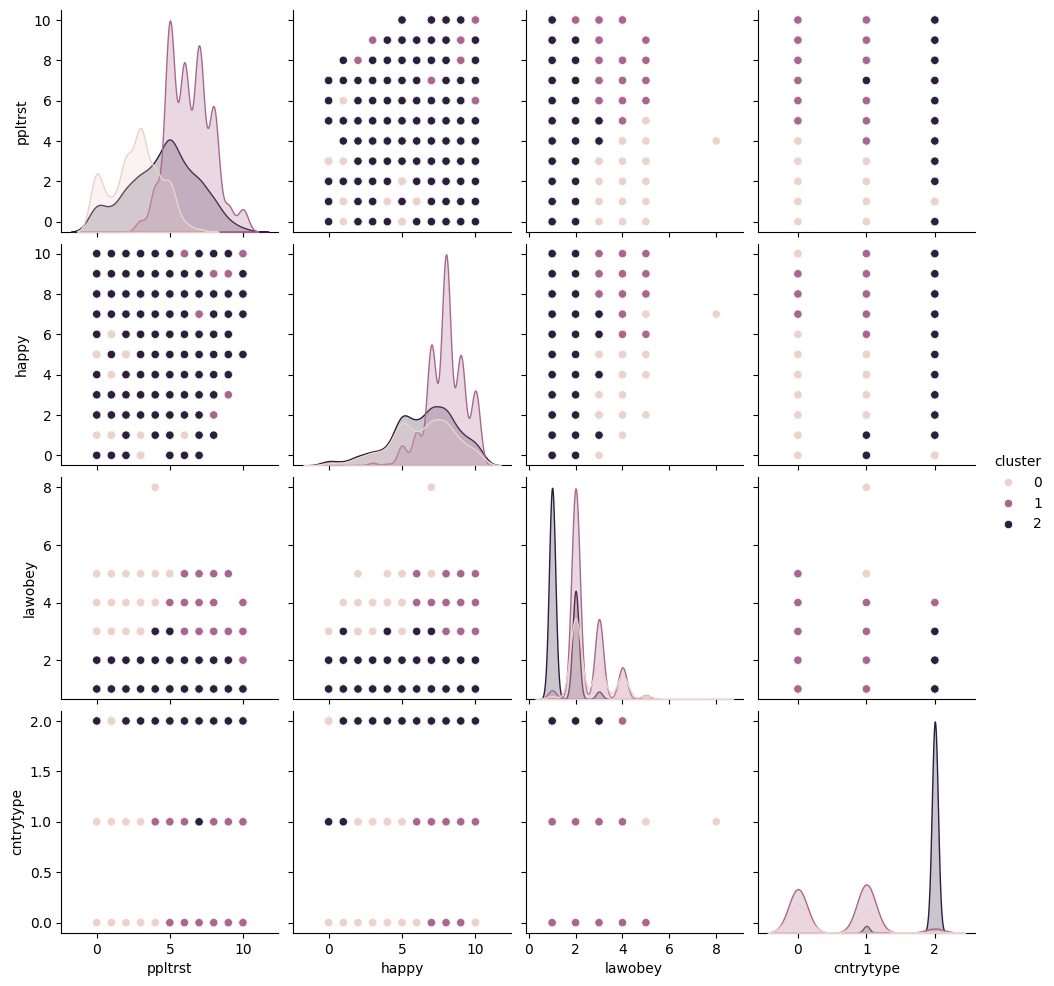

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_scatter_matrix(df_clustered, features):

    sns.pairplot(df_clustered, vars=features, hue='cluster')
    plt.show()

features = ['ppltrst', 'happy', 'lawobey', 'cntrytype']
visualize_scatter_matrix(df_clustered, features)

In [42]:
df_clustered.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_eu.csv', index=False)


In [43]:
del df_deu_sample, df_spa_sample, df_hun_sample, features, mean, std

In [44]:
import pandas as pd
import numpy as np
#Creamos variables derivadas y rellenamos datos faltantes si fuera necesario.
def variablesderivadas(df):

    trust_variables = ['trstplc', 'trstlgl', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci']
    df['trst_mean'] = df[trust_variables].mean(axis=1)
    df['trst_happy'] = df['trst_mean'] * df['happy']
    df['trstplc_trstlgl_diff'] = df['trstplc'] - df['trstlgl']
    df['felicidad'] = pd.cut(df['happy'], bins=[0, 3, 6, 10], labels=['0', '1', '2'])
    df['confianza'] = pd.cut(df['ppltrst'], bins=[0, 3, 6, 10], labels=['0', '1', '2'])
    df['ideologia'] = pd.cut(df['lrscale'], bins=[0, 3, 6, 10], labels=['0', '1', '2'])
    df['trstplc_trstlgl_diff'] = df['trstplc_trstlgl_diff'].apply(lambda x: 0 if x < 0 else x)
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].round(1)
    for col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    return df



df_clustered = variablesderivadas(df_clustered)
for col in df_clustered.columns:
    if pd.api.types.is_numeric_dtype(df_clustered[col]):
        print(f"Valores únicos en {col}: {df_clustered[col].unique()}")

print(df_clustered.isnull().sum())


Valores únicos en pplhlp: [ 5.  4.  7.  6.  2.  0.  3.  8.  9. 10.  1.]
Valores únicos en ppltrst: [ 4.  5.  9.  7.  6.  0.  3.  2.  8. 10.  1.]
Valores únicos en lawobey: [2. 3. 4. 5. 1. 8.]
Valores únicos en lrscale: [ 5.  4.  2.  7.  8.  6.  3. 10.  1.  0.  9.]
Valores únicos en stfgov: [ 6.  7.  1.  2.  0.  3.  8.  5.  4.  9. 10.]
Valores únicos en trstep: [ 6.  7.  8.  2.  3.  1.  5.  4.  0. 10.  9.]
Valores únicos en trstlgl: [ 5.  8. 10.  7.  0.  6.  9.  3.  4.  2.  1.]
Valores únicos en trstplc: [ 5.  8.  7.  6.  9.  0.  4. 10.  2.  3.  1.]
Valores únicos en trstplt: [ 5.  7.  1.  3.  2.  6.  9.  4.  0.  8. 10.]
Valores únicos en trstprl: [ 7.  6.  8.  1.  3.  4.  5.  9.  2.  0. 10.]
Valores únicos en trstprt: [ 6.  5.  1.  3.  2.  0.  4.  9.  7.  8. 10.]
Valores únicos en trstun: [ 6.  8.  1.  5.  3.  4.  7.  0.  9.  2. 10.]
Valores únicos en trstsci: [ 8.  9.  7.  6.  2.  3.  4. 10.  5.  0.  1.]
Valores únicos en happy: [ 8.  5.  9. 10.  7.  6.  2.  4.  3.  1.  0.]
Valores ún

C:\Users\Josue;\AppData\Local\Temp\ipykernel_7500\1451894888.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Josue;\AppData\Local\Temp\ipykernel_7500\1451894888.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [45]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
def convert_to_integers(df, columns):


    for col in columns:
        df[col] = df[col].astype(int)

    return df


columns_to_convert = ['pplhlp', 'ppltrst', 'lawobey', 'lrscale', 'stfgov', 'trstep',
                       'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt',
                       'trstun', 'trstsci', 'happy','trstplc_trstlgl_diff','felicidad','cntrytype','cluster','confianza','ideologia']

df_clustered = convert_to_integers(df_clustered, columns_to_convert)

# Verificar los tipos de datos después de la conversión
print(df_clustered.dtypes)

def scale_round_decimal(df, columns):


    scaler = MinMaxScaler()

    for col in columns:
        # Aplicar Min-Max scaling
        df[col] = scaler.fit_transform(df[[col]])

        # Redondear a un decimal
        df[col] = df[col].round(1)

    return df

columns_to_process = ['trst_mean', 'trst_happy']
df_clustered = scale_round_decimal(df_clustered, columns_to_process)
for col in columns_to_process:
    print(f"Valores únicos en {col}: {df_clustered[col].unique()}")
print(df_clustered.dtypes)

pplhlp                    int64
ppltrst                   int64
lawobey                   int64
lrscale                   int64
stfgov                    int64
trstep                    int64
trstlgl                   int64
trstplc                   int64
trstplt                   int64
trstprl                   int64
trstprt                   int64
trstun                    int64
trstsci                   int64
happy                     int64
cntrytype                 int64
cluster                   int64
trst_mean               float64
trst_happy              float64
trstplc_trstlgl_diff      int64
felicidad                 int64
confianza                 int64
ideologia                 int64
dtype: object
Valores únicos en trst_mean: [0.6 0.7 0.8 0.4 0.5 0.9 0.3 0.2 0.1 0.  1. ]
Valores únicos en trst_happy: [0.5 0.6 0.4 0.2 0.8 0.3 0.1 0.7 0.  0.9 1. ]
pplhlp                    int64
ppltrst                   int64
lawobey                   int64
lrscale                   int64
stf

In [46]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def minmax_var(df, columns):
    scaler = MinMaxScaler()
    for col in columns:
        # Aplicar Min-Max scaling
        df[col + '_mmx'] = scaler.fit_transform(df[[col]])

        # Redondear a un decimal
        df[col + '_mmx'] = df[col + '_mmx'].round(1)

    return df

columns_to_convert = ['pplhlp', 'ppltrst', 'lrscale', 'stfgov', 'trstep',
                       'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt',
                       'trstun', 'trstsci', 'happy', 'trstplc_trstlgl_diff']

df_mmxeu = minmax_var(df_clustered, columns_to_convert)


for col in columns_to_convert:
    print(f"Valores únicos en {col}_mmx: {df_clustered[col + '_mmx'].unique()}")
print(df_mmxeu.dtypes)

Valores únicos en pplhlp_mmx: [0.5 0.4 0.7 0.6 0.2 0.  0.3 0.8 0.9 1.  0.1]
Valores únicos en ppltrst_mmx: [0.4 0.5 0.9 0.7 0.6 0.  0.3 0.2 0.8 1.  0.1]
Valores únicos en lrscale_mmx: [0.5 0.4 0.2 0.7 0.8 0.6 0.3 1.  0.1 0.  0.9]
Valores únicos en stfgov_mmx: [0.6 0.7 0.1 0.2 0.  0.3 0.8 0.5 0.4 0.9 1. ]
Valores únicos en trstep_mmx: [0.6 0.7 0.8 0.2 0.3 0.1 0.5 0.4 0.  1.  0.9]
Valores únicos en trstlgl_mmx: [0.5 0.8 1.  0.7 0.  0.6 0.9 0.3 0.4 0.2 0.1]
Valores únicos en trstplc_mmx: [0.5 0.8 0.7 0.6 0.9 0.  0.4 1.  0.2 0.3 0.1]
Valores únicos en trstplt_mmx: [0.5 0.7 0.1 0.3 0.2 0.6 0.9 0.4 0.  0.8 1. ]
Valores únicos en trstprl_mmx: [0.7 0.6 0.8 0.1 0.3 0.4 0.5 0.9 0.2 0.  1. ]
Valores únicos en trstprt_mmx: [0.6 0.5 0.1 0.3 0.2 0.  0.4 0.9 0.7 0.8 1. ]
Valores únicos en trstun_mmx: [0.6 0.8 0.1 0.5 0.3 0.4 0.7 0.  0.9 0.2 1. ]
Valores únicos en trstsci_mmx: [0.8 0.9 0.7 0.6 0.2 0.3 0.4 1.  0.5 0.  0.1]
Valores únicos en happy_mmx: [0.8 0.5 0.9 1.  0.7 0.6 0.2 0.4 0.3 0.1 0. ]
Valor

In [47]:

df_mmxeu.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/df_mmxeu.csv', index=False)


In [48]:
df_ideo = df_mmxeu.copy().drop(['lrscale', 'lrscale_mmx'], axis=1)

In [51]:
import pandas as pd
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import roc_auc_score
import os

def bestclassifier(df, target_column, feature_range):
    results = {}
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    best_model = None
    best_accuracy = -float('inf')
    best_auc = -float('inf')
    best_k = 0
    best_features = []

    for k in range(feature_range[0], feature_range[1] + 1):
        selector = SelectKBest(score_func=chi2, k=k)
        X_train_selected = selector.fit_transform(X_train, y_train)
        X_test_selected = selector.transform(X_test)

        clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

        
        clf.models = {name: model for name, model in clf.models.items() if name != 'NearestCentroid'}

        models, predictions = clf.fit(X_train_selected, X_test_selected, y_train, y_test)
        results[k] = models

        top_model_name = models.index[0]
        top_model_accuracy = models.loc[top_model_name, 'Accuracy']
        top_model_auc = roc_auc_score(y_test, predictions[top_model_name])
        models.loc[top_model_name, 'AUC'] = top_model_auc

        if top_model_auc > best_auc:
            best_accuracy = top_model_accuracy
            best_auc = top_model_auc
            best_model = top_model_name
            best_k = k
            best_features = X.columns[selector.get_support()].tolist()

    output_dir = 'C:/Users/Josue/4GA.Datascience/4GA.DataScience/App'
    os.makedirs(output_dir, exist_ok=True)

    with open(os.path.join(output_dir, 'bestclassifier.txt'), 'w') as f:
        f.write(f"Mejor modelo: {best_model}\n")
        f.write(f"Accuracy: {best_accuracy}\n")
        f.write(f"AUC: {best_auc}\n")
        f.write(f"Número de características: {best_k}\n")
        f.write(f"Características: {best_features}\n")

    return results, best_model, best_k, best_features



results, best_model, best_k, best_features = bestclassifier(df_ideo, 'ideologia', (10, 18))

print(f"Mejor modelo: {best_model}")
print(f"Número de características: {best_k}")
print(f"Características: {best_features}")

100%|██████████| 32/32 [00:01<00:00, 18.15it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 99
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 10
[LightGBM] [Info] Start training from score -1.517923
[LightGBM] [Info] Start training from score -0.536143
[LightGBM] [Info] Start training from score -1.630491


KeyError: 'NearestCentroid'

In [ ]:

    results = {}
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    best_model = None
    best_accuracy = -float('inf')
    best_auc = -float('inf')
    best_k = 0
    best_features = []

    for k in range(feature_range[0], feature_range[1] + 1):
        selector = SelectKBest(score_func=chi2, k=k)
        X_train_selected = selector.fit_transform(X_train, y_train)
        X_test_selected = selector.transform(X_test)

        clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None) #Eliminamos exclude
        models, predictions = clf.fit(X_train_selected, X_test_selected, y_train, y_test)
        results[k] = models

        top_model_name = models.index[0]
        top_model_accuracy = models.loc[top_model_name, 'Accuracy']
        top_model_auc = roc_auc_score(y_test, predictions[top_model_name])
        models.loc[top_model_name, 'AUC'] = top_model_auc

        if top_model_auc > best_auc:
            best_accuracy = top_model_accuracy
            best_auc = top_model_auc
            best_model = top_model_name
            best_k = k
            best_features = X.columns[selector.get_support()].tolist()

    output_dir = 'C:/Users/Josue/4GA.Datascience/4GA.DataScience/App'
    os.makedirs(output_dir, exist_ok=True)

    with open(os.path.join(output_dir, 'bestclassifier.txt'), 'w') as f:
        f.write(f"Mejor modelo: {best_model}\n")
        f.write(f"Accuracy: {best_accuracy}\n")
        f.write(f"AUC: {best_auc}\n")
        f.write(f"Número de características: {best_k}\n")
        f.write(f"Características: {best_features}\n")

    return results, best_model, best_k, best_features

# Ejemplo de uso (asumiendo que df_ideo ya está cargado)
# ... (carga de df_ideo)

results, best_model, best_k, best_features = bestclassifier(df_ideo, 'ideologia', (10, 18))

print(f"Mejor modelo: {best_model}")
print(f"Número de características: {best_k}")
print(f"Características: {best_features}")

In [ ]:
import pandas as pd
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
import os

def bestmodel(df, target_column, feature_range):
    


    results = {}
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    best_model = None
    best_r_squared = -float('inf')
    best_k = 0
    best_features = []

    for k in range(feature_range[0], feature_range[1] + 1):
        selector = SelectKBest(score_func=f_regression, k=k)
        X_train_selected = selector.fit_transform(X_train, y_train)
        X_test_selected = selector.transform(X_test)

        reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
        models, predictions = reg.fit(X_train_selected, X_test_selected, y_train, y_test)
        results[k] = models

        top_model_name = models.index[0]
        top_model_r_squared = models.loc[top_model_name, 'R-Squared']

        if top_model_r_squared > best_r_squared:
            best_r_squared = top_model_r_squared
            best_model = top_model_name
            best_k = k
            best_features = X.columns[selector.get_support()].tolist()

    output_dir = 'C:/Users/Josue/4GA.Datascience/4GA.DataScience/App'
    os.makedirs(output_dir, exist_ok=True)

    with open(os.path.join(output_dir, 'bestmodel.txt'), 'w') as f:
        f.write(f"Mejor modelo: {best_model}\n")
        f.write(f"R-cuadrado: {best_r_squared}\n")
        f.write(f"Número de características: {best_k}\n")
        f.write(f"Características: {best_features}\n")

    return results, best_model, best_k, best_features

results, best_model, best_k, best_features = bestmodel(df_mmxeu, 'lrscale_mmx', (10, 18))
print(f"Mejor modelo: {best_model}")
print(f"Número de características: {best_k}")
print(f"Características: {best_features}")